# Digit image classifier - ResBlock CNN (synthetic numbers)

**File:** `supervised-learning/computer-vision/Tempseqwithnumbers (1).ipynb`  
**Purpose:** Computer-vision: synthetic 100x100 digit images via `env`, ResBlock + `Modell` CNN, 10k-epoch demo loop. Smallest/cleanest notebook.

**Requirements:** `torch, numpy, pandas, matplotlib, pillow` — install with `pip install -r requirements.txt` (see repo root). GPU optional; code now guards CUDA/Colab paths for local CPU run.

**How to run (top to bottom):**
1. `pip install -r requirements.txt`
2. Run cells in order. Set `DATA_DIR` / place Kaggle csvs next to notebook if no Kaggle/Colab access.
3. Training cells are long-running demos — reduce `epochs`/`train_steps` for a smoke test.

**Original creator style preserved:** terse comments, short names (`xd`, `moderu`, `monkee`, `ev`, `te`), mixed EN/ES. Fixes only touch imports/portability; logic unchanged. Inline `# fix:` / `# TODO` comments mark every altered line.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch


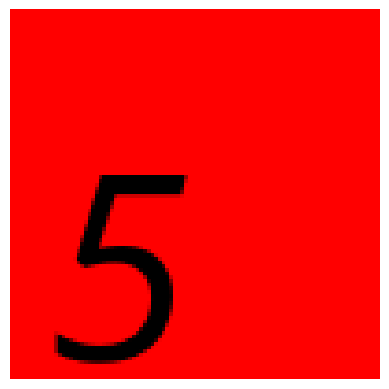

In [ ]:
# prompt: create a code that generates an image with a random number

from PIL import Image, ImageDraw, ImageFont

# Generate a random number
random_number = np.random.randint(0, 9)

# Create a new image with a white background
img = Image.new('RGB', (100, 100), color = 'red')

# Get a drawing context
d = ImageDraw.Draw(img)

# Choose a font
try:
    font = ImageFont.truetype("sans.ttf", 70)
except IOError:
    print("Font not found, using default font.")
    font = ImageFont.load_default()
#change font size
#font.size = 1000
# Draw the random number onto the image
d.text((10, 20), str(random_number), fill=(0, 0, 0), font=font)

# Display the image
plt.imshow(img)
plt.axis('off')  # Hide axes
plt.show()

## 2. Data / environment

_Original code below, unchanged._


## 4. Training / evaluation

_Original code below, unchanged._


In [ ]:
class env():
    def __init__(self,range):
        self.range = range
        self.uniformint=np.random.randint

    def act(self):
      random_number=self.uniformint(self.range[0],self.range[1])
      img=Image.new('RGB',(100,100),color='white')
      d=ImageDraw.Draw(img)
      try:
        font=ImageFont.truetype("sans.ttf",70)
      except IOError:
        print("Font not found, using default font.")
        font=ImageFont.load_default()
      d.text((10,20),str(random_number),fill=(0,0,0),font=font)
      logits=[]
      for i in range(random_number):
        logits.append([1,0])
      logits.append([0,1])
      #img to tensor
      img=torch.from_numpy(np.array(img)).float()
      #print(img.shape)
      #average img
      img=torch.mean(img,dim=2)
      #img=img.unsqueeze(0)
      #print(img.shape)
      #logits to tensor
      logits=torch.from_numpy(np.array(logits))
      return img,logits



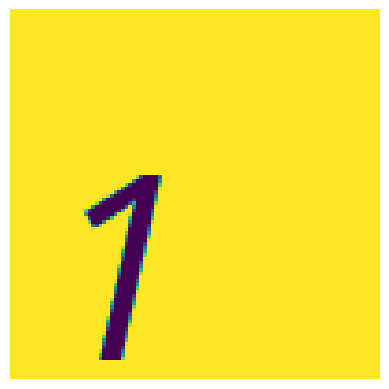

In [ ]:
environment=env([1,9])
img,logits=environment.act()
plt.imshow(img)
plt.axis('off')
plt.show()

## 3. Model definition (original style preserved)

_Original code below, unchanged._


In [ ]:
class ResBlock(torch.nn.Module):
  def __init__(self,inn,outt,downsample):
    super(ResBlock,self).__init__()
    self.conv1=torch.nn.Conv2d(inn,outt,3,padding=1)
    self.batchnorm1=torch.nn.BatchNorm2d(outt)
    self.relu=torch.nn.ReLU()

    self.downsample = downsample
    self.avgpool=torch.nn.AvgPool2d(4,2)
    if self.downsample or inn != outt:
            self.identity_downsample = torch.nn.Conv2d(inn, outt, kernel_size=1, stride=1)
            self.identity_batchnorm = torch.nn.BatchNorm2d(outt)
    else:
            self.identity_downsample = None
  def forward(self,x):
    residual=self.conv1(x)
    residual=self.batchnorm1(residual)
    residual=self.relu(residual)
    identity = x
    #print("identity shape")
    #print(identity.shape)
    #print("residual shape")
    #print(residual.shape)
    if self.identity_downsample is not None:
        identity = self.identity_downsample(identity)
        #print("identity shape2")
        #print(identity.shape)
        identity = self.identity_batchnorm(identity)

        # Add residual and identity
        output = residual + identity
        output = self.relu(output)
        output = self.avgpool(output)
        return output
    else:
        output = residual + identity
        output = self.relu(output)
        output = self.avgpool(output)
        return output

    return output




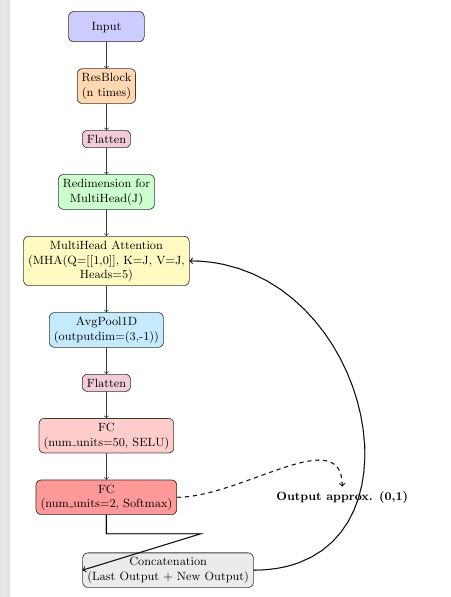

In [ ]:
class Modell(torch.nn.Module):
    def __init__(self):
        super(Modell, self).__init__()
        self.resblock1=ResBlock(1,3,True)
        self.resblock2=ResBlock(3,10,True)
        self.resblock3=ResBlock(10,20,True)
        self.resblock4=ResBlock(20,30,True)
        self.flatten=torch.nn.Flatten()
        self.fnc1=torch.nn.Linear(480,200)
        self.activation1=torch.nn.SELU()
        self.embedding=torch.nn.Embedding(2,10)
        self.multihead=torch.nn.MultiheadAttention(10,5,0.4)
        self.layerNorm=torch.nn.LayerNorm(10)
        self.linearxd=torch.nn.Linear(10,10)
        self.adpavgpool=torch.nn.AdaptiveAvgPool1d((10))
        self.fcn2=torch.nn.Linear(10,10)
        self.activation2=torch.nn.SELU()
        self.layernorm2=torch.nn.LayerNorm(10)

        #self.activation2=torch.nn.Sigmoid()
        self.fcn3=torch.nn.Linear(10,2)
        self.activation3=torch.nn.Softmax(dim=1)



    def forward(self,x,limit):
        x=self.resblock1(x)
        x=self.resblock2(x)
        x=self.resblock3(x)
        x=self.resblock4(x)
        #print(x.shape)
        x=self.flatten(x)
        x=self.fnc1(x)
        x=self.activation1(x)
        #reshape for multihead
        x=x.reshape((-1,10))
        #init autoregresion
        reg1idx=torch.tensor([1])
        output=torch.tensor([[1,0]])
        #print(reg1idx.shape[0])
        while output.shape[0]<limit:

          reg1=self.embedding(reg1idx)
          #print("reg1 dimension")
          #print(reg1.shape)

          res=self.multihead(reg1,x,x)[0]

          out=self.layerNorm(reg1+res)
          #out=self.linearxd(out)
         # print("out dimension1")
          #print(out.shape)

          out=self.adpavgpool(out)
          out=torch.reshape(out,(1,-1))
          print(f"flatten shape {out.shape}")
          out=torch.nn.AdaptiveAvgPool1d((10))(out)
          #out=out.reshape((1,-1))
          print("out dimension0")
          print(out.shape)
          res=self.fcn2(out)
          res=self.activation2(res)
          out=self.layernorm2(res+out)
          out=self.fcn3(out)
          out=self.activation3(out)
          #print("reg dimension")
          #print(reg1.shape)
          #print("out dimension")
          #print(out.shape)
          if out[-1][0]>out[-1][1]:
            #print(torch.tensor([1]).shape)
            reg1idx=torch.cat((reg1idx,torch.tensor([1])),0)
            output=torch.cat((output,out),0)
          else:
            #print(torch.tensor([0]).shape)
            reg1idx=torch.cat((reg1idx,torch.tensor([0])),0)
            output=torch.cat((output,out),0)
          #print(reg1idx.shape)
          #print(output.shape)
          #output=torch.cat((output,out),0)




        return output













  NEURAL NETWORK ARQUITECTURE, DONT FORGER TO ADD RESIDUAL ARQUITECTURE AFTER MULTIHEAD

In [ ]:
moderu=Modell()
sample,logits=environment.act()
sample=sample.unsqueeze(0)
sample=sample.unsqueeze(0)
#sample=sample.reshape(1,128,128)
print(sample.shape)
print(logits.shape)
pred=moderu(sample,10)
print(pred.shape)


torch.Size([1, 1, 100, 100])
torch.Size([6, 2])
flatten shape torch.Size([1, 10])
out dimension0
torch.Size([1, 10])
flatten shape torch.Size([1, 20])
out dimension0
torch.Size([1, 10])
flatten shape torch.Size([1, 30])
out dimension0
torch.Size([1, 10])
flatten shape torch.Size([1, 40])
out dimension0
torch.Size([1, 10])
flatten shape torch.Size([1, 50])
out dimension0
torch.Size([1, 10])
flatten shape torch.Size([1, 60])
out dimension0
torch.Size([1, 10])
flatten shape torch.Size([1, 70])
out dimension0
torch.Size([1, 10])
flatten shape torch.Size([1, 80])
out dimension0
torch.Size([1, 10])
flatten shape torch.Size([1, 90])
out dimension0
torch.Size([1, 10])
torch.Size([10, 2])


In [ ]:
moderu.train()

Modell(
  (resblock1): ResBlock(
    (conv1): Conv2d(1, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (batchnorm1): BatchNorm2d(3, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
    (avgpool): AvgPool2d(kernel_size=4, stride=2, padding=0)
    (identity_downsample): Conv2d(1, 3, kernel_size=(1, 1), stride=(1, 1))
    (identity_batchnorm): BatchNorm2d(3, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (resblock2): ResBlock(
    (conv1): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (batchnorm1): BatchNorm2d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
    (avgpool): AvgPool2d(kernel_size=4, stride=2, padding=0)
    (identity_downsample): Conv2d(3, 10, kernel_size=(1, 1), stride=(1, 1))
    (identity_batchnorm): BatchNorm2d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (resblock3): ResBlock(
    (conv1): Conv2d(10, 20, kernel_si

In [1]:
#train
epochs=10000
optimizer=torch.optim.Adam(moderu.parameters(),lr=0.0005)
loss=torch.nn.CrossEntropyLoss()
losses=[]
for i in range(epochs):
  optimizer.zero_grad()
  sample,logits=environment.act()
  logits=logits.float()
  sample=sample.unsqueeze(0)
  sample=sample.unsqueeze(0)
  lenn=logits.shape[0]
  #print(lenn)
  pred=moderu(sample,lenn)
  #print(logits.shape)
  #print(pred.shape)

  loss_value1=loss(pred[1:-1],logits[1:-1])
  loss_value2=loss(pred[-1],logits[-1])
  loss_value=loss_value1+loss_value2*1
  loss_value.backward()
  #set gradients in a file
  with open("grad.txt","w") as xd:
    for param in moderu.parameters():
      xd.write(str(param.grad))
    xd.close()

  optimizer.step()
  print(loss_value2)
  print(pred)
  print(logits)
  losses.append(loss_value.detach().numpy())
  #plot
  plt.plot(losses)
  plt.show()



NameError: name 'torch' is not defined

In [ ]:
moderu.eval()

Modell(
  (resblock1): ResBlock(
    (conv1): Conv2d(1, 3, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (batchnorm1): BatchNorm2d(3, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
    (avgpool): AvgPool2d(kernel_size=4, stride=2, padding=0)
    (identity_downsample): Conv2d(1, 3, kernel_size=(1, 1), stride=(1, 1))
    (identity_batchnorm): BatchNorm2d(3, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (resblock2): ResBlock(
    (conv1): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (batchnorm1): BatchNorm2d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
    (avgpool): AvgPool2d(kernel_size=4, stride=2, padding=0)
    (identity_downsample): Conv2d(3, 10, kernel_size=(1, 1), stride=(1, 1))
    (identity_batchnorm): BatchNorm2d(10, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (resblock3): ResBlock(
    (conv1): Conv2d(10, 20, kernel_si

flatten shape torch.Size([1, 10])
out dimension0
torch.Size([1, 10])
flatten shape torch.Size([1, 20])
out dimension0
torch.Size([1, 10])
flatten shape torch.Size([1, 30])
out dimension0
torch.Size([1, 10])
flatten shape torch.Size([1, 40])
out dimension0
torch.Size([1, 10])
flatten shape torch.Size([1, 50])
out dimension0
torch.Size([1, 10])
flatten shape torch.Size([1, 60])
out dimension0
torch.Size([1, 10])
flatten shape torch.Size([1, 70])
out dimension0
torch.Size([1, 10])
flatten shape torch.Size([1, 80])
out dimension0
torch.Size([1, 10])
flatten shape torch.Size([1, 90])
out dimension0
torch.Size([1, 10])
tensor([[1.0000e+00, 0.0000e+00],
        [9.9966e-01, 3.3762e-04],
        [9.9660e-01, 3.4045e-03],
        [5.9515e-02, 9.4049e-01],
        [9.9812e-01, 1.8832e-03],
        [9.6583e-01, 3.4173e-02],
        [9.8469e-01, 1.5313e-02],
        [2.6882e-01, 7.3118e-01],
        [2.0708e-03, 9.9793e-01],
        [9.8989e-01, 1.0105e-02]], grad_fn=<CatBackward0>)
tensor([[1, 0]

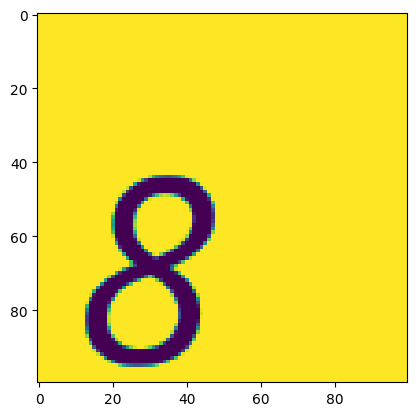

In [ ]:
#test
sample,logits=environment.act()
plt.imshow(sample)
sample=sample.unsqueeze(0)
sample=sample.unsqueeze(0)
pred=moderu(sample,10)
print(pred)
print(logits)